# Laste ned data fra Cloud Native

In [ ]:
%%capture
%pip install rasterio matplotlib

In [88]:
from pathlib import Path

import matplotlib.pyplot as plt
import rasterio
from rasterio.plot import show

Path("nedlastinger").mkdir(exist_ok=True)

## Strømming

Du kan enkelt lese Cloud Native Geo via en URL. GDAL bruker [virtuelle filsystemer](https://kartaistorage.blob.core.windows.net/skygeo/toporaster/cog/33_n2000raster_1.tif) og kommandoene blir de samme som om filen ligger lokalt.

Eksempelet under viser informasjon om filen med `gdalinfo`.

In [12]:
!gdalinfo /vsicurl/https://kartaistorage.blob.core.windows.net/skygeo/toporaster/cog/33_n2000raster_1.tif

Driver: GTiff/GeoTIFF
Files: /vsicurl/https://kartaistorage.blob.core.windows.net/skygeo/toporaster/cog/33_n2000raster_1.tif
Size is 20000, 20000
Coordinate System is:
PROJCRS["ETRS89 / UTM zone 33N",
    BASEGEOGCRS["ETRS89",
        ENSEMBLE["European Terrestrial Reference System 1989 ensemble",
            MEMBER["European Terrestrial Reference Frame 1989"],
            MEMBER["European Terrestrial Reference Frame 1990"],
            MEMBER["European Terrestrial Reference Frame 1991"],
            MEMBER["European Terrestrial Reference Frame 1992"],
            MEMBER["European Terrestrial Reference Frame 1993"],
            MEMBER["European Terrestrial Reference Frame 1994"],
            MEMBER["European Terrestrial Reference Frame 1996"],
            MEMBER["European Terrestrial Reference Frame 1997"],
            MEMBER["European Terrestrial Reference Frame 2000"],
            MEMBER["European Terrestrial Reference Frame 2005"],
            MEMBER["European Terrestrial Reference 

## Hele fila

Dersom du trenger hele fila offline kan du bare laste den ned med f.eks. `curl`. Cloud Optimized formater er laget for å være mest mulig bakoverkompatible og skal fungere like godt lokalt.

In [68]:
!curl -L -o nedlastinger/helefila.tif https://kartaistorage.blob.core.windows.net/skygeo/toporaster/cog/33_n5000raster_1.tif

  % Total    % Received % Xferd  Average Speed  Time    Time    Time   Current
                                 Dload  Upload  Total   Spent   Left   Speed

  0      0   0      0   0      0      0      0                              0
 62  4.06M  62  2.53M   0      0  2.52M      0   00:01   00:01          2.53M
100  4.06M 100  4.06M   0      0  2.67M      0   00:01   00:01          2.53M
100  4.06M 100  4.06M   0      0  2.67M      0   00:01   00:01          2.53M
100  4.06M 100  4.06M   0      0  2.67M      0   00:01   00:01          2.53M


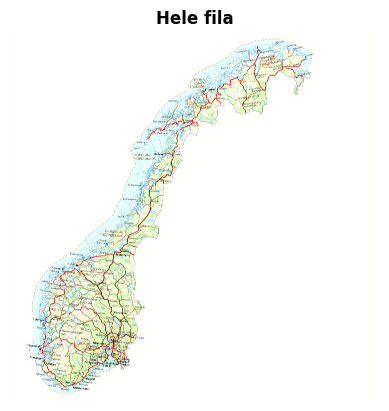

In [82]:
with rasterio.open("nedlastinger/helefila.tif") as src:
    _, ax = plt.subplots()
    show(src, title="Hele fila", ax=ax)
    ax.axis("off")

## Utsnitt

Her bruker vi `gdal_translate` til å laste ned et utsnitt. Vi gir `-projwin` øverste venstre hjørne og nederste høyre hjørne fra dette polygonet: `POLYGON ((7.48 58.08,8.64 58.08,8.64 58.66,7.48 58.66,7.48 58.08))`.

In [79]:
!gdal_translate \
    -projwin 7.48 58.66 8.64 58.08 \
    -projwin_srs EPSG:4326 \
    /vsicurl/https://kartaistorage.blob.core.windows.net/skygeo/toporaster/cog/33_n5000raster_1.tif \
    nedlastinger/utsnitt.tif

Input file size is 8000, 8000
0...10...20...30...40...50...60...70...80...90...100 - done.


ERROR 1: Deleting nedlastinger/utsnitt.tif failed:
Permission denied


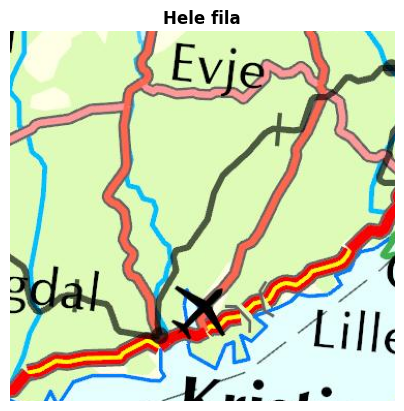

In [84]:
with rasterio.open("nedlastinger/utsnitt.tif") as src:
    _, ax = plt.subplots()
    show(src, title="Hele fila", ax=ax)
    ax.axis("off")

## Klippejobb

Ved å peke på en geometri med `-cutline` kan GDAL klippe dataene. I eksempelet under bruker vi en GeoJSON med geometrien til Agder fylke (denne kan også hentes fra URL).

In [86]:
!gdalwarp \
    -of GTiff \
    -overwrite \
    -cutline /vsicurl/https://kartaistorage.blob.core.windows.net/skygeo/administrative-enheter/42.json \
    -cutline_srs EPSG:4326 \
    -crop_to_cutline \
    /vsicurl/https://kartaistorage.blob.core.windows.net/skygeo/toporaster/cog/33_n5000raster_1.tif \
    nedlastinger/klippejobb.tif

Creating output file that is 1060P x 1072L.
Processing 33_n5000raster_1.tif [1/1] : 0...10...20...30...40...50...60...70...80...90...100 - done.


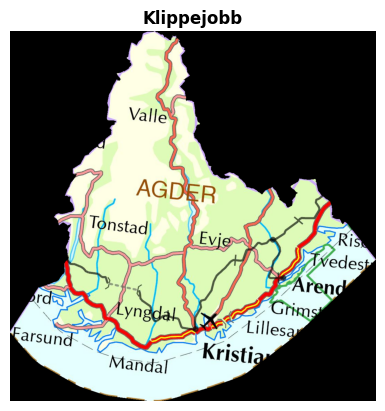

In [87]:
with rasterio.open("nedlastinger/klippejobb.tif") as src:
    _, ax = plt.subplots()
    show(src, title="Klippejobb", ax=ax)
    ax.axis("off")